Import packages and construct list of DEMs (stored in dems var).

In [65]:
from pathlib import Path #to access data by path
import topotoolbox as ttb #to handle data
import matplotlib.pyplot as plt #for plotting
import numpy as np #for handling large amounts of data (arrays not lists)
from datetime import datetime as dt #to process the date of dems
import rioxarray as rxr


rasterFolder = Path('Snow Depth Rasters')
dems = [] #snow depth dems

# #loop through each file in snow rasters folder
for file in Path("Snow Depth Rasters").iterdir():
    #ensure file is .tif
    if file.is_file() and file.suffix.lower() == '.tif':
        dem = ttb.read_tif(file)
        dems.append(dem)

bsDem = ttb.read_tif(r"NonDepthData\MTBS_Resampled_1m.tif") #raster containing burn severity data
sfDem = ttb.read_tif(r"NonDepthData\DEM_063025_SnowFree.tif") #raster of snow free slope

iVarDems = [] #dems of indepent variables ex: burn severity

iVarDems.append(sfDem)
iVarDems.append(bsDem)

Create a box plot based on parameters: data (array of numerical values), title (plot title), dataLabel (label describing the numerical data), and criteriaLabel (special criteria this dataset meets).

In [66]:
def makeBoxPlot(data : np.array, title : str, dataLabel : str, criteriaLabel : str):
    if len(data) <= 1: return

    #Setup plot
    plt.figure(figsize=(8, 4))
    plt.boxplot(data)

    #Setup labels
    plt.title(title)
    plt.xlabel(criteriaLabel)
    plt.ylabel(dataLabel)

    #Show plot
    plt.show()

Create a scatter plot based on parameters: xData, yData, title, xLabel, and yLabel

In [67]:
def makeScatterPlot(xData : np.array, yData : np.array, title : str, xLabel : str, yLabel : str):
    
    #Setup graph
    plt.figure(figsize=(8, 4))
    plt.scatter(xData, yData)

    #Setup labels
    plt.title(title)
    plt.xlabel(xLabel)
    plt.ylabel(yLabel)

    #Show graph
    plt.show()

Function that takes the raw name of a dem and processes it into a readable format.

In [68]:
def processDemName(rawName : str):
    rawDate = rawName.split("_")[1] #get date string from name (will take whatever string comes after the first underscore)
    date = dt.strptime(rawDate, "%m%d%y").date() #get date object from string
    name = "Lidar drone data - " + date.strftime("%m/%d/%y") #convert date object back to string
    return name

-import SD rasters, import DEM, LAI, burn severity

-use topotoolbox to generate slope, aspect, northness, eastness rasters

-create scatter plots of snow depth on each date vs independent variables

Filters out improper depths from Lidar and returns a np.array. (Array will contain np.nan, which will need to be filtered for plotting)

In [69]:
#filter out any points less than -0.1 or greater than 5, if a remaining value is less than 0 it will be set to zero
def filterLidarDepth(depths):
    depths[depths < -0.1] = np.nan 
    depths[depths > 5.0] = np.nan
    depths[depths < 0] = 0 
    return depths

Process snow depth data and make plots.

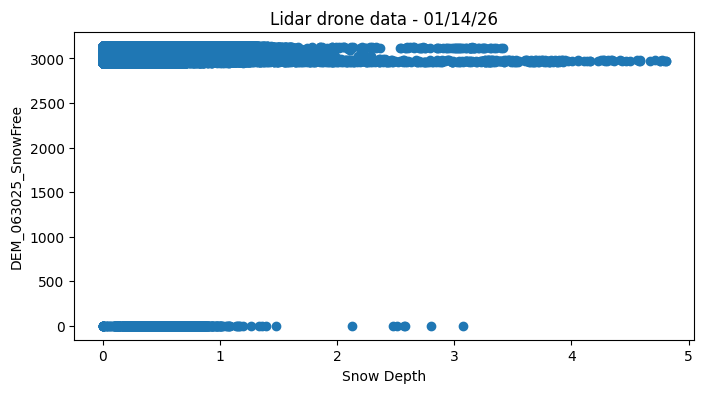

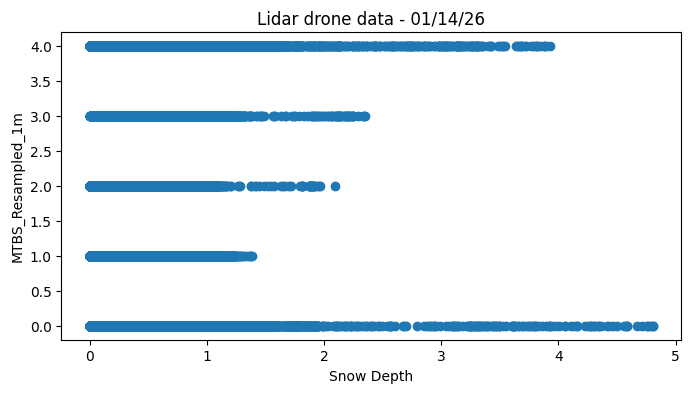

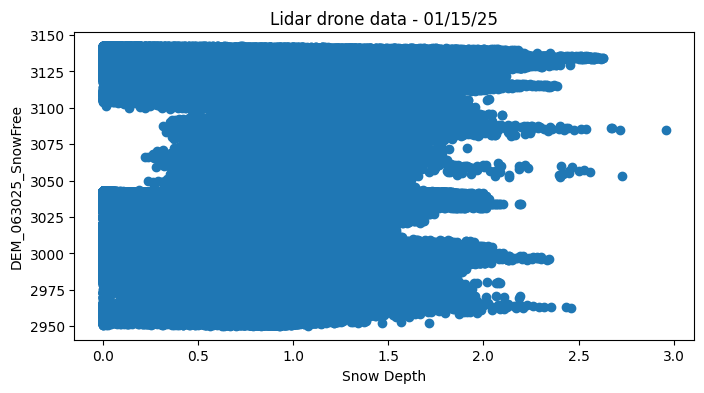

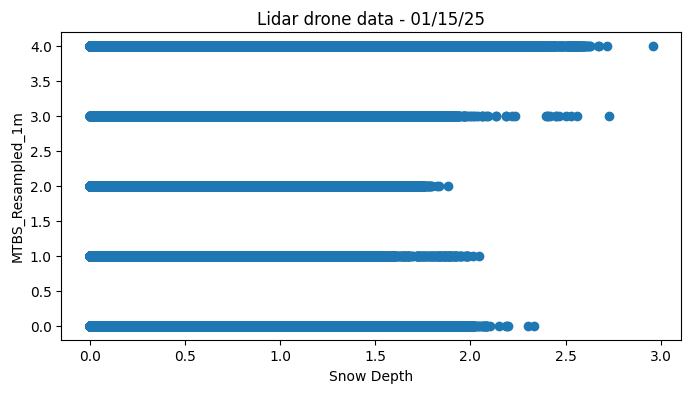

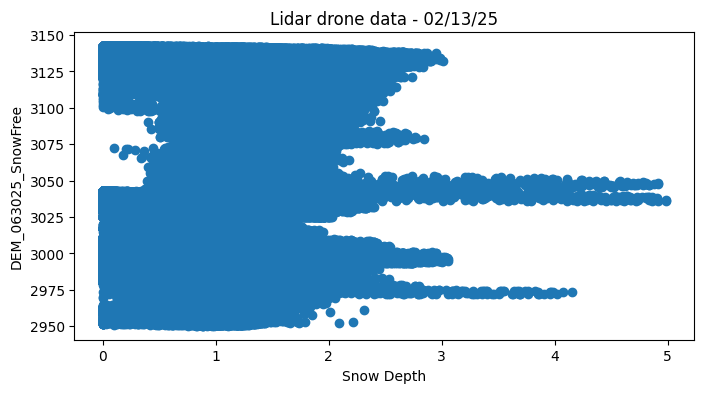

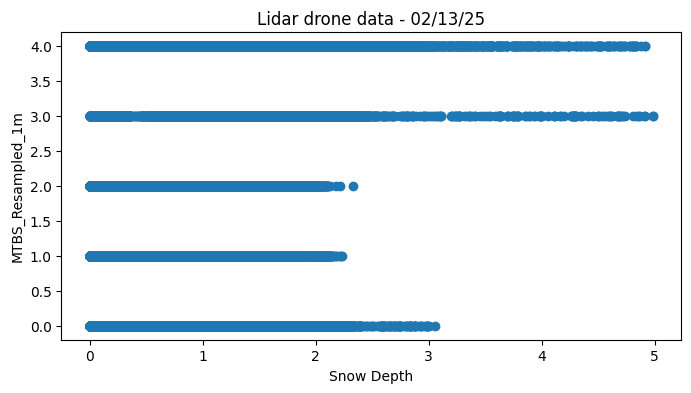

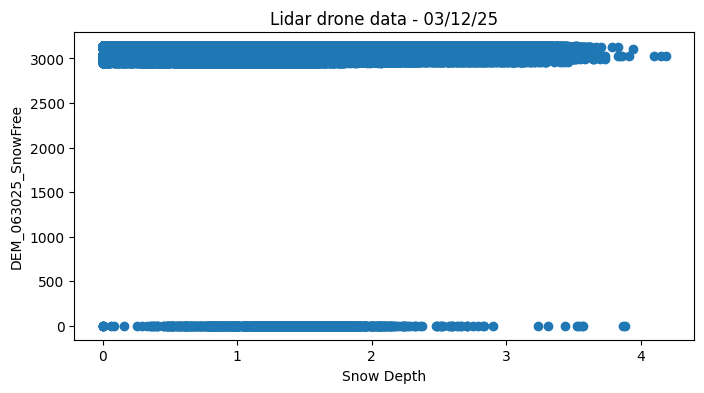

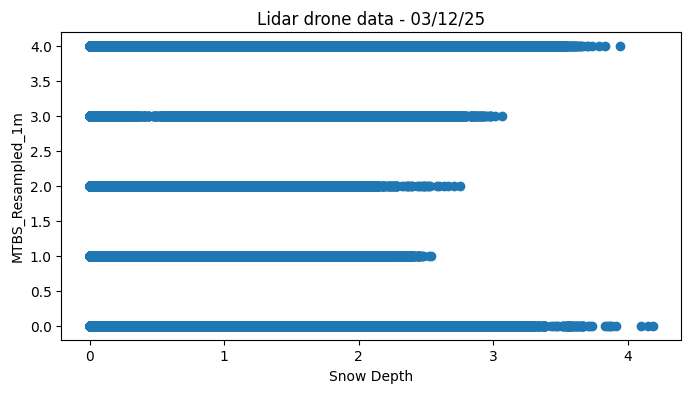

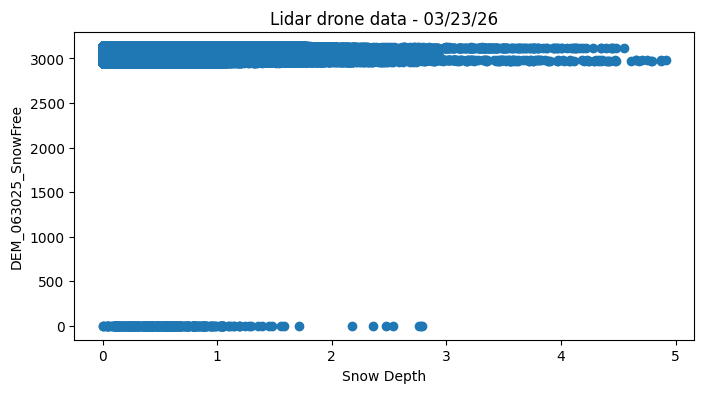

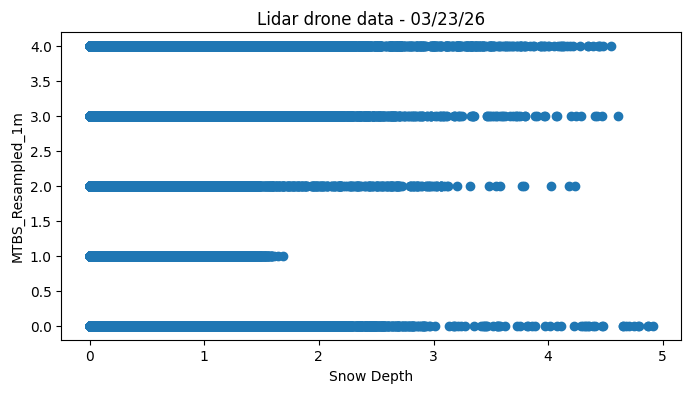

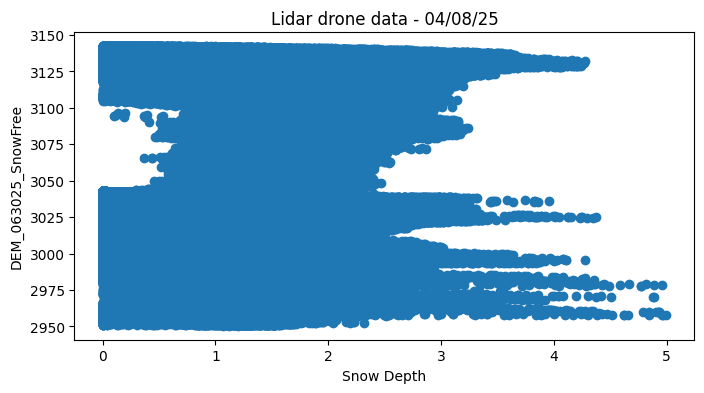

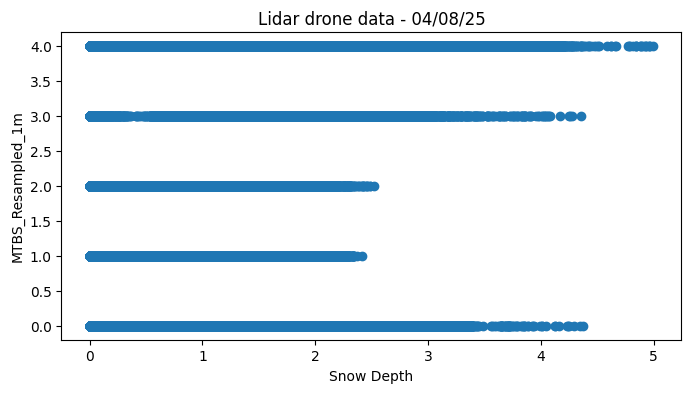

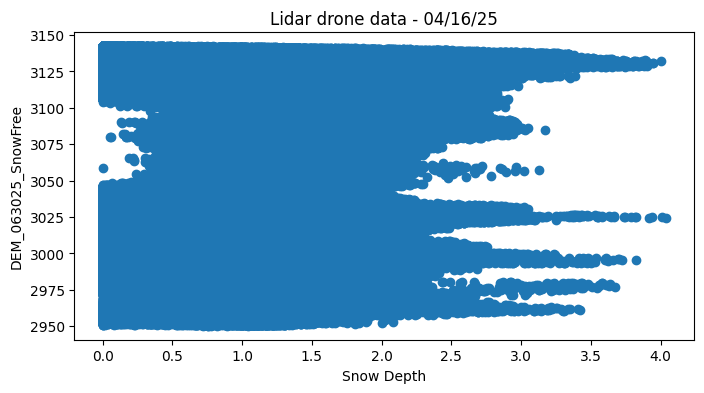

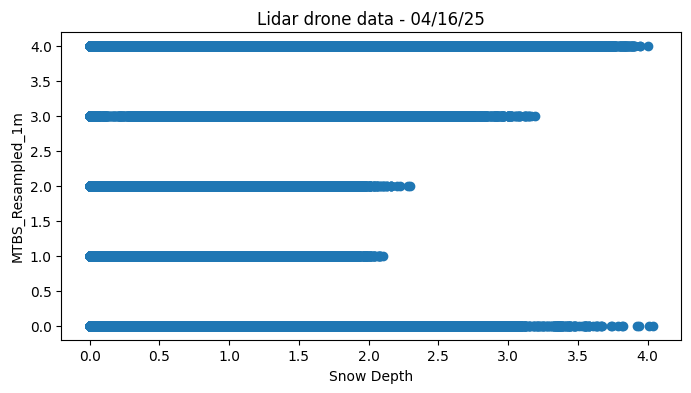

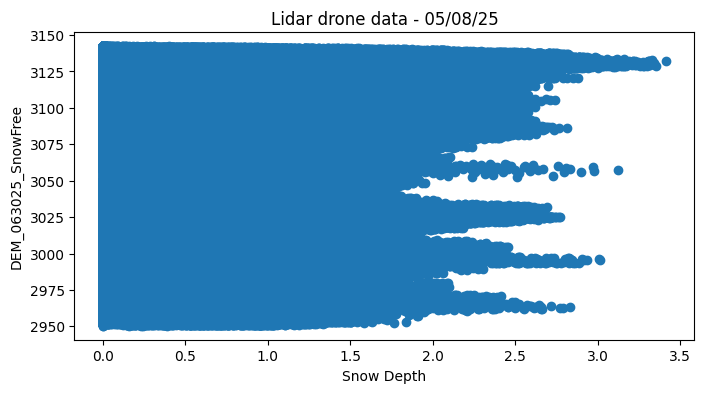

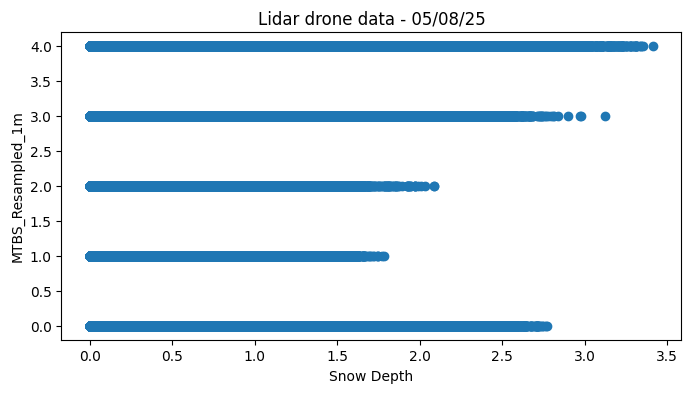

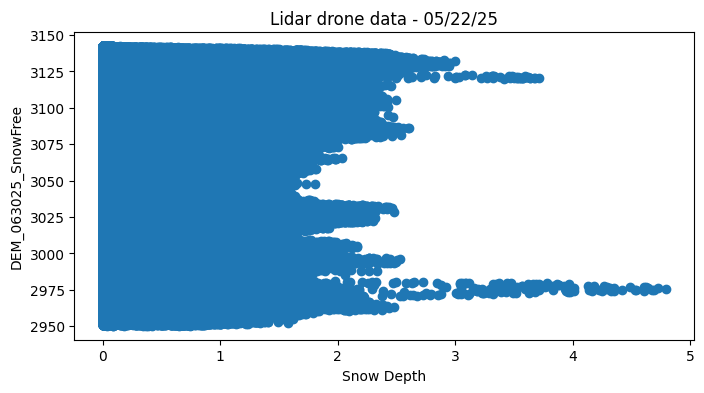

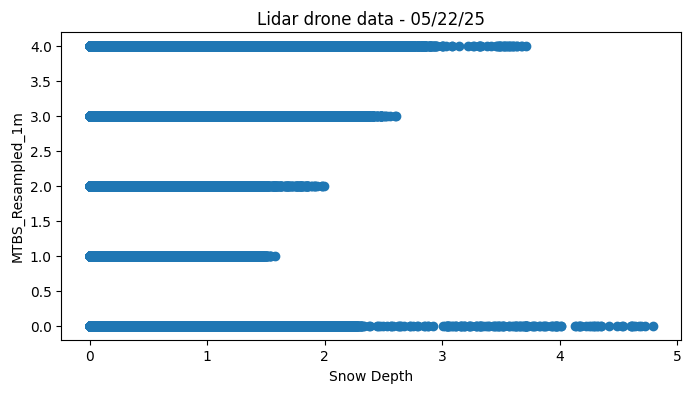

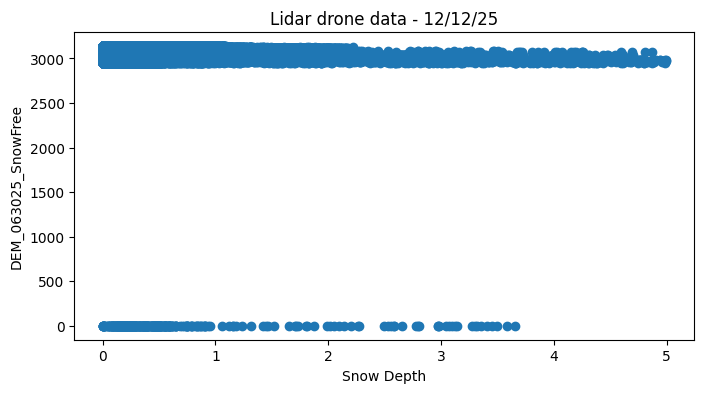

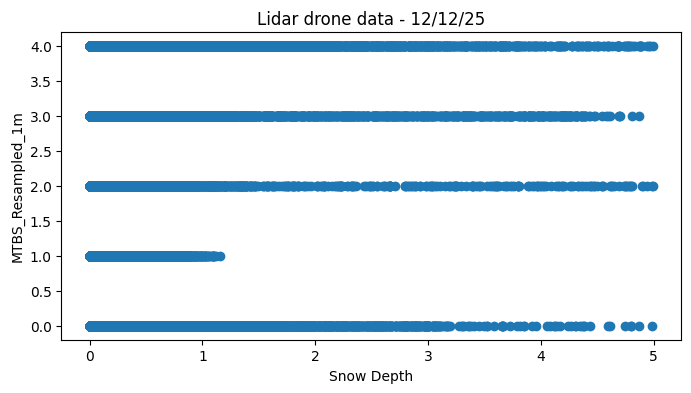

In [ ]:
for dem in dems:
    # -------------Box plot ---------------
    # make box plot of depths

    # depths = dem.z.ravel()
    # depths = filterLidarDepth(depths)
    # depthsClean = depths[~np.isnan(depths)]
    # makeBoxPlot(depthsClean, processDemName(dem.name), "Snow Depth", "All data (Outliers removed)")

    # -------------Scatter plot -----------
    # #make scatter plot of depths against all independent variables

    for iVarDem in iVarDems:

        #----Resample-----
        #open both as xarray objects
        demRx = rxr.open_rasterio(dem.path)
        iVarRx = rxr.open_rasterio(iVarDem.path)
        #resample depths to match iVar's resolution
        demResampled = demRx.rio.reproject_match(iVarRx)
        #create depths and iVarData (flattened arrays of now resampled grids)
        depths = filterLidarDepth(demResampled.values.ravel().astype(float))
        iVarData = iVarRx.values.ravel().astype(float)

        if len(depths) == len(iVarData):
            #filter out any points where depths or iVarData is nan
            validMask = ~np.isnan(depths) & ~np.isnan(iVarData)
            makeScatterPlot(depths[validMask], iVarData[validMask], processDemName(dem.name), "Snow Depth", iVarDem.name)
        else:
            print("RESOLUTIONS DID NOT MATCH: " + dem.name)
            print("depths-size:" + str(dem.shape))
            print("independent-size: " + str(iVarDem.shape))